In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import nct

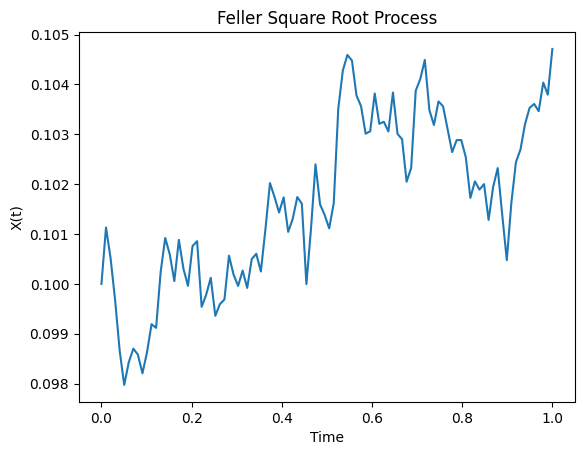

In [ ]:
# Parameters
kappa = 1.0  # Rate of mean reversion
theta = 0.1  # Long-term mean
sigma = 0.02  # Volatility
X0 = 0.1  # Initial value
T = 1.0  # Total time
dt = 0.01  # Time step size
N = int(T / dt)  # Number of time steps

# Initialize array to store the process values
X = np.zeros(N)
X[0] = X0

# Simulate the process
for n in range(1, N):
    Z = np.random.normal(0, 1)  # Standard normal random variable
    X[n] = X[n-1] + kappa * (theta - X[n-1]) * dt + sigma * np.sqrt(X[n-1]) * np.sqrt(dt) * Z

# Time vector
t = np.linspace(0, T, N)

# Plot the process
plt.plot(t, X)
plt.title('Feller Square Root Process')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.show()


In [24]:
# Parameters and time grid
npaths = 20000  # Number of paths
T = 1          # Time horizon
nsteps = 200   # Number of time steps
dt = T / nsteps  # Time step
t = np.linspace(0, T, nsteps + 1)  # Observation times
alpha = 5      # Mean reversion speed
mu = 0.07      # Long-term mean
sigma = 0.265  # Volatility
X0 = 0.03      # Initial value

In [27]:
# Feller ratio for monitoring
Feller_ratio = 2 * alpha * mu / sigma**2
print(f"Feller ratio: {Feller_ratio}")

Feller ratio: 9.967960128159486


In [28]:
# Monte Carlo simulation: Euler-Maruyama method
X = np.zeros((nsteps + 1, npaths))
X[0, :] = X0  # Initial value for all paths

# Generate random numbers
N = np.random.randn(nsteps, npaths)

# Compute analytic moments
a = sigma**2 / alpha * (np.exp(-alpha * dt) - np.exp(-2 * alpha * dt))  # With analytic moments
b = mu * sigma**2 / (2 * alpha) * (1 - np.exp(-alpha * dt))**2  # With analytic moments

# Compute and accumulate the increments using Euler-Maruyama method with analytic moments
for i in range(nsteps):
    X[i + 1, :] = mu + (X[i, :] - mu) * np.exp(-alpha * dt) + np.sqrt(a * X[i, :] + b) * N[i, :]
    X[i + 1, :] = np.maximum(X[i + 1, :], 0)  # Ensure X doesn't go below zero

Text(0.5, 1.0, 'Paths of a Feller square-root process $dX = \\alpha(\\mu - X)dt + \\sigma X^{1/2} dW$')

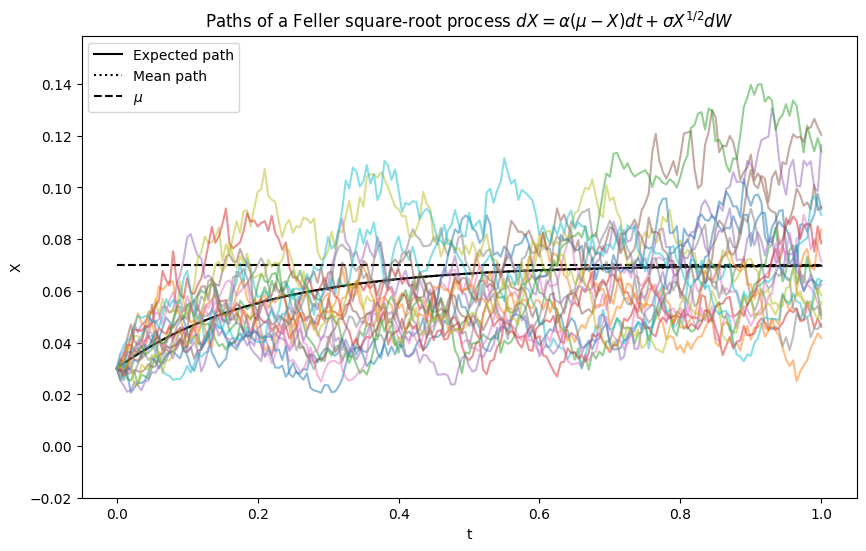

In [31]:
# 1. Expected, mean, and sample paths
plt.figure(figsize=(10, 6))
EX = mu + (X0 - mu) * np.exp(-alpha * t)  # Expected path
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, np.mean(X, axis=1), ':k', label='Mean path')
plt.plot(t, mu * np.ones_like(t), 'k--', label=r'$\mu$')
plt.plot(t, X[:, ::1000], alpha=0.5)  # Plot a subset of paths for clarity
plt.legend()
plt.xlabel('t')
plt.ylabel('X')
sdevinfty = sigma * np.sqrt(mu / (2 * alpha))
plt.ylim([-0.02, mu + 4 * sdevinfty])
plt.title(r'Paths of a Feller square-root process $dX = \alpha(\mu - X)dt + \sigma X^{1/2} dW$')
